# Regression Problem - Predicting GDP Based on COVID-19 Data

## Goal
Predict the GDP of a country based on COVID-19 statistics and economic indicators using supervised learning regression models.

## Data Preparation

### Imports

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


### Loading the Dataset

In [36]:
df = pd.read_csv("Excel Files/Covid19_With_GDP_Values.csv")
df.head()

,Unnamed: 0,Country/Region,Date,Province/State,Confirmed,Deaths,Recovered,GDP,Unemployment,CPI
0,0,Afghanistan,2021-01-01,0,52513.0,2201.0,41727.0,1.426650e+10,11.934,NaN
1,1,Afghanistan,2022-01-01,0,158107.0,7356.0,0.0,1.450216e+10,14.100,NaN
2,2,Albania,2021-01-01,0,58316.0,1181.0,33634.0,1.793057e+10,12.473,123.448662
3,3,Albania,2022-01-01,0,210224.0,3217.0,0.0,1.891638e+10,11.588,131.750835
4,4,Algeria,2021-01-01,0,99897.0,2762.0,67395.0,1.862654e+11,13.607,166.218895


### Step 1 - Removing Unknown and Meaningless Columns

**`Unnamed: 0`** - This column is an artifact from the CSV export process. It is a duplicate of the DataFrame's default integer index and carries no meaningful information. Removing it avoids redundancy.

In [37]:
df = df.drop("Unnamed: 0", axis=1)

### Step 2 & 3 - Handling Missing Values and Removing Duplicates

**Missing values:** We chose to drop rows containing missing values (`dropna`) rather than imputing them. Since the dataset is relatively small and each row represents a country-year observation, imputing values (e.g., with the mean) could introduce misleading data — for example, filling in a missing CPI value with the global average would not accurately reflect that specific country's economic situation. Dropping these rows ensures that only complete and reliable observations are used for training.

**Duplicates:** Duplicate rows are removed to prevent the model from being biased toward countries that appear more than once with identical data.

In [38]:
df = df.dropna().drop_duplicates()

### Step 4 - Aggregating Data by Country (with smart handling of `Recovered`)

The dataset contains two rows per country (2021 and 2022). We aggregate to one row per country so each observation is independent.

**`Recovered` needs special treatment.** Inspecting the raw data shows that **every 2022 row has `Recovered = 0`** — this isn't a real measurement, it's a reporting change (countries stopped publishing recovery counts in 2022). Naively averaging the real 2021 value with a structural zero would silently halve the feature for every country and feed the model a biased signal. We mark the 2022 `Recovered` cells as `NaN` so `groupby().mean()` ignores them, leaving each country's `Recovered` equal to its 2021 value. `Confirmed` and `Deaths` continue to be averaged across both years (their 2022 values are real).

Before aggregating, we also drop columns that cannot be meaningfully averaged:
- **`Date` / `Year`** — categorical time labels; averaging them has no interpretation.
- **`Province/State`** — constant 0 for the rows we kept; no predictive value.


In [ ]:
df["Year"] = pd.to_datetime(df["Date"]).dt.year

# 2022 Recovered is structurally zero (reporting change) — exclude it from the country mean
df.loc[df["Year"] == 2022, "Recovered"] = np.nan

df = df.drop(["Date", "Province/State", "Year"], axis=1)
df = df.groupby("Country/Region").mean()
df.head()


### Step 5 - Engineering a Case-Fatality Ratio

`Confirmed` and `Deaths` are extremely correlated (~0.95) — both are essentially "how big was the outbreak in this country." That's mostly a country-size signal, not a healthcare-quality signal. We add a derived feature, `CaseFatality = Deaths / Confirmed`, which is a per-country *intensity* roughly independent of country size and captures something the raw counts cannot (healthcare capacity, age structure, reporting accuracy).

The ratio lives on `[0, ~0.1]` so it does **not** need a log transform — only the heavy-tailed magnitude features below do.


In [ ]:
df["CaseFatality"] = df["Deaths"] / df["Confirmed"].replace(0, np.nan)
df["CaseFatality"] = df["CaseFatality"].fillna(0)
df.head()


### Step 6 - Log-Transforming Skewed Variables

`GDP`, `Confirmed`, `Deaths`, and `Recovered` all span many orders of magnitude across countries (`GDP` alone ranges from ~$1B to ~$23T). On the raw scale, no linear model can fit such a wide range cleanly — the fit is dominated by a few large countries.

We apply `np.log1p` (= `log(1 + x)`) to compress the range and make the relationships more linear. `log1p` is used instead of `log` so that zero values are handled safely.

**Why not log-transform CPI?** CPI looks tempting to log because of one extreme value (Zimbabwe, ~8200), but in practice log-CPI compresses the real spread in the other ~165 countries enough that it hurts model performance. The regularization in Ridge/Lasso already handles the Zimbabwe outlier without needing a transform. **Why not log CaseFatality?** It is already a bounded ratio in `[0, ~0.1]` — no compression needed.

Note that **GDP is now on a log-dollar scale**, so all reported MAE/MSE/RMSE values below are in log-GDP units rather than dollars.


In [ ]:
for col in ["GDP", "Confirmed", "Deaths", "Recovered"]:
    df[col] = np.log1p(df[col])
df.head()


### Step 7 - Separating Features and Label

After aggregation and feature engineering, `Country/Region` is the index of the DataFrame, and all remaining columns are numerical — there are no categorical features to encode with `get_dummies()`.

We separate the data into:
- **X (features):** Confirmed, Deaths, Recovered, Unemployment, CPI, CaseFatality
- **y (label):** GDP


In [41]:
X = df.drop("GDP", axis=1)
y = df["GDP"]

## Data Exploration

In this section we examine the relationships between all features and the label (GDP) using:
1. A **pairplot** to visually inspect feature-to-feature and feature-to-label relationships.
2. **Scatter plots** of each feature against GDP for a closer look.
3. A **correlation heatmap** to quantify these relationships numerically.

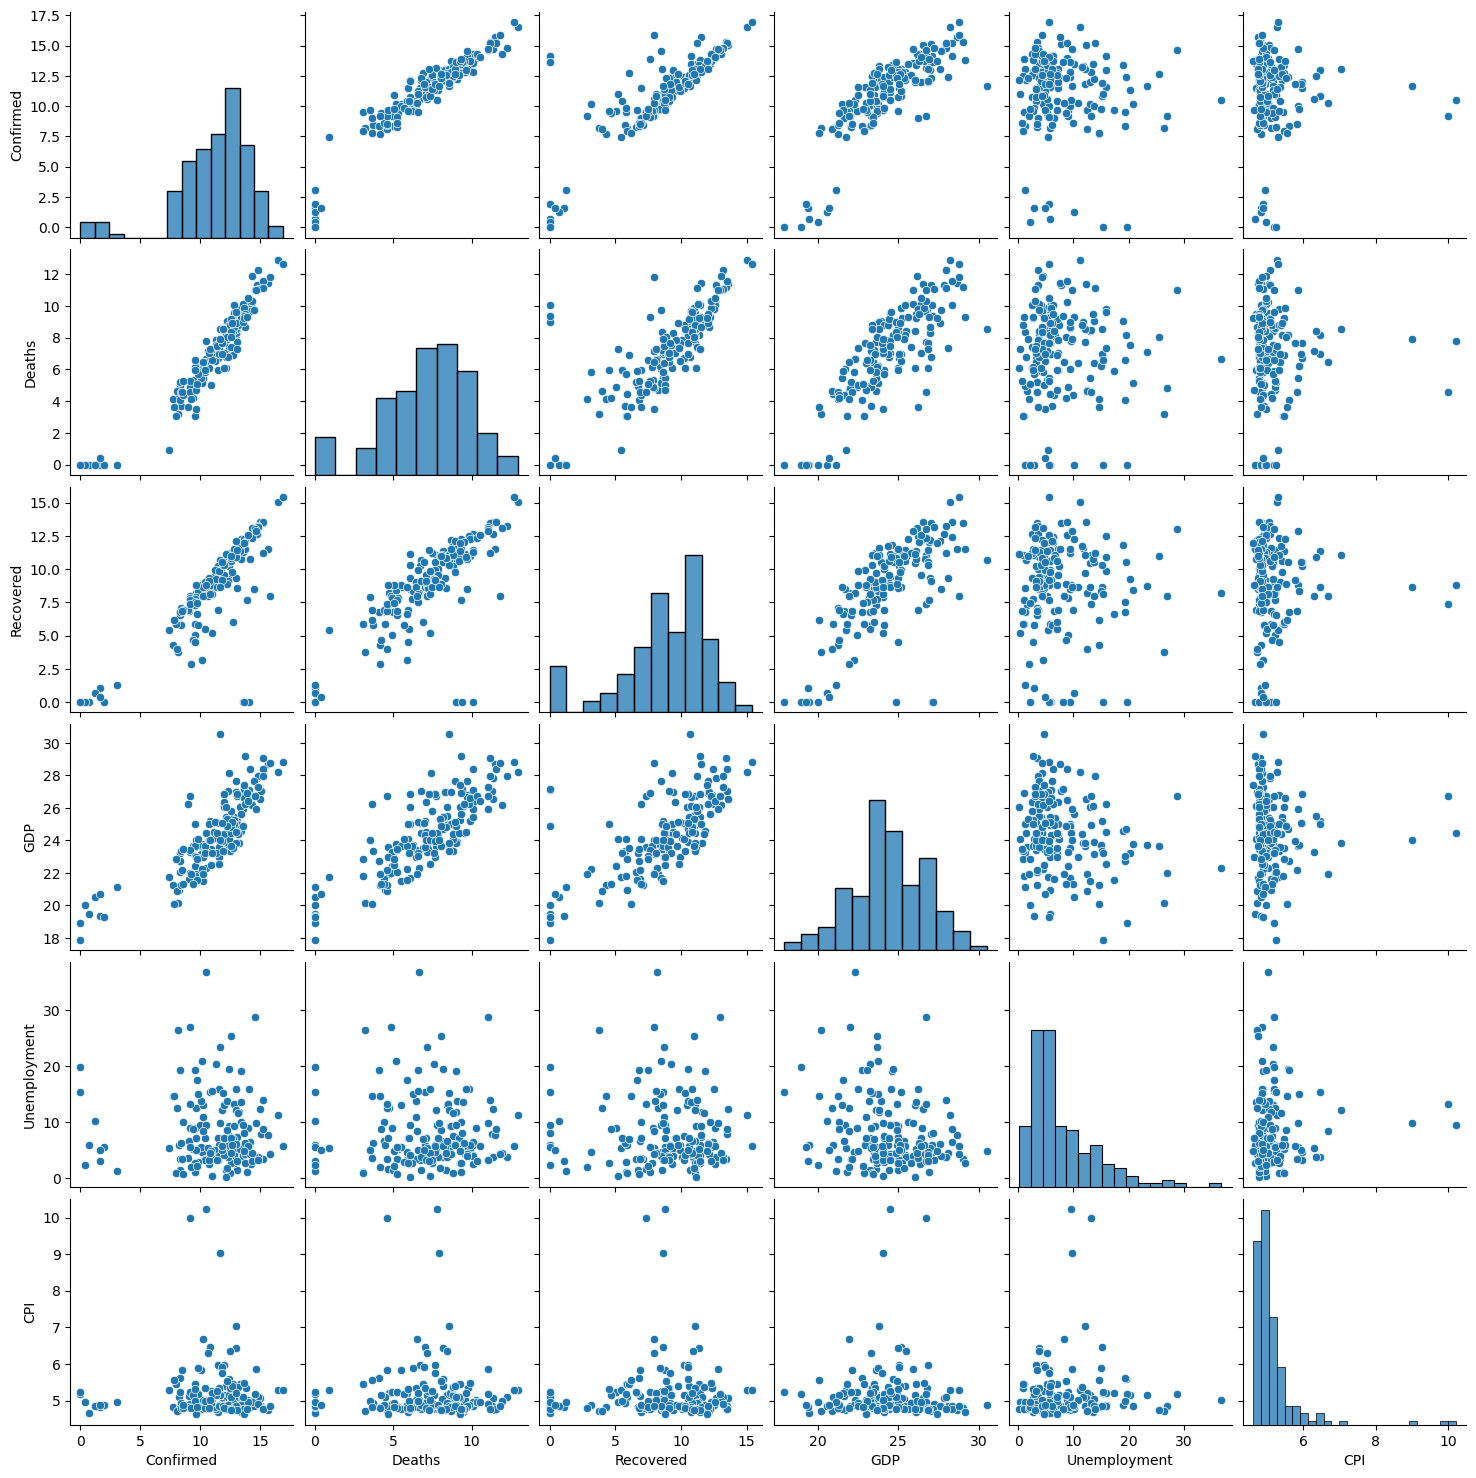

In [42]:
sns.pairplot(data=df)

### Pairplot Observations

**Feature-to-feature relationships:**
- **Confirmed** and **Deaths** show a near-perfect linear relationship (countries with more cases have proportionally more deaths). **Recovered** also tracks them, though more loosely now that it is a 2021-only value rather than a noisy 2-year average. This multicollinearity is exactly why we add `CaseFatality` as a derived feature and why Ridge/Lasso regularization is appropriate downstream.
- **CaseFatality** does *not* track the count features — it is a ratio, so it is roughly independent of outbreak size. That is the whole point of engineering it.

**Feature-to-label (GDP) relationships:**
- **Confirmed**, **Deaths**, and **Recovered** all show a clear positive trend with GDP on the log scale. Wealthier countries report more cases, both because they have larger populations and because their testing/reporting infrastructure is better.
- **CPI** still shows weak linear pattern with GDP and contains extreme outliers (values above 8000, likely due to hyperinflation in countries like Zimbabwe). We deliberately leave it on the raw scale — log-transforming it ended up hurting model performance because it compressed real spread in the other ~165 countries (Ridge/Lasso regularization handles the outlier without needing a transform).
- **Unemployment** shows no clear linear pattern with GDP.
- **CaseFatality** shows a mild negative trend with GDP — wealthier countries had lower fatality rates, consistent with better healthcare and earlier vaccine access.

**Distribution shapes (diagonal histograms):**
- After `log1p`, `GDP`, `Confirmed`, `Deaths`, and `Recovered` are roughly bell-shaped — much closer to normal than the raw right-skewed distributions.
- `CPI`, `Unemployment`, and `CaseFatality` were left on their original scales.


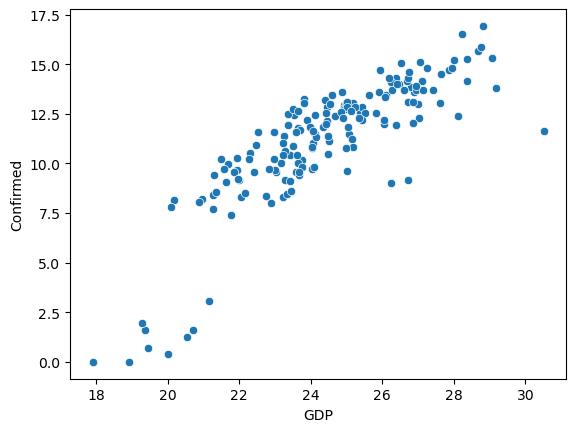

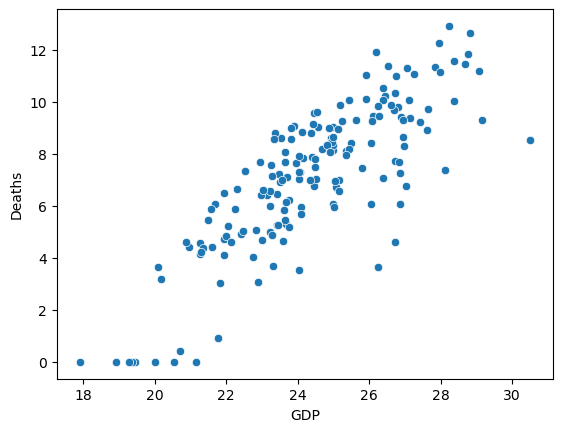

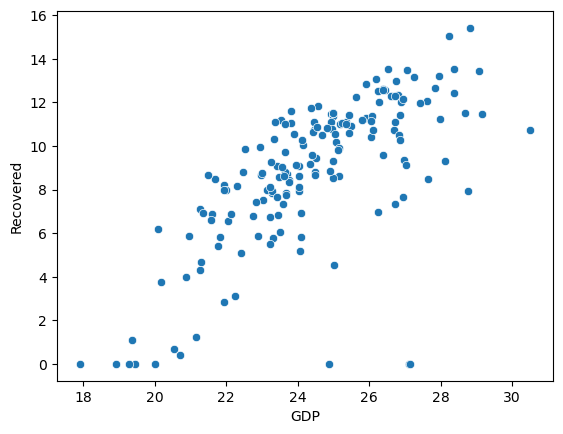

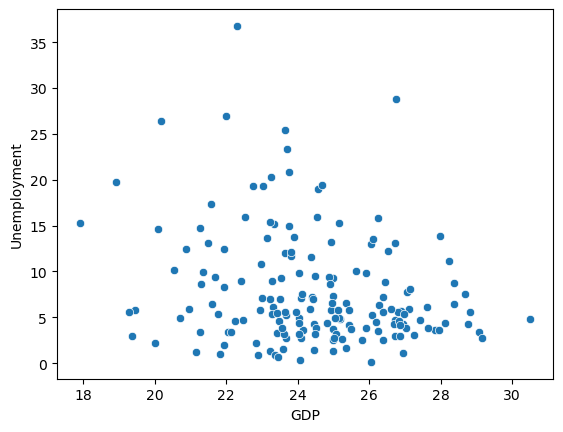

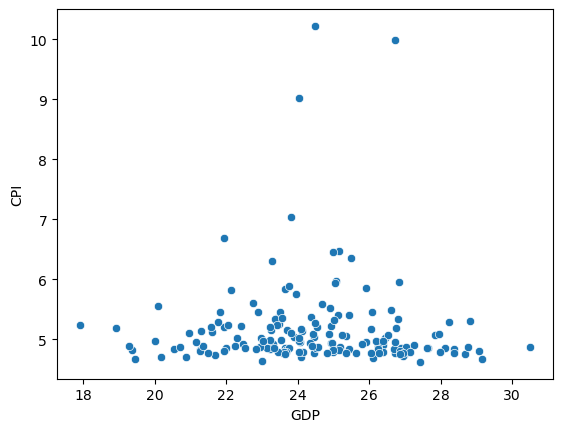

In [43]:
for col in df.columns:
    if col != "GDP":
        sns.scatterplot(data=df, x="GDP", y=col)
        plt.show()

<Axes: >

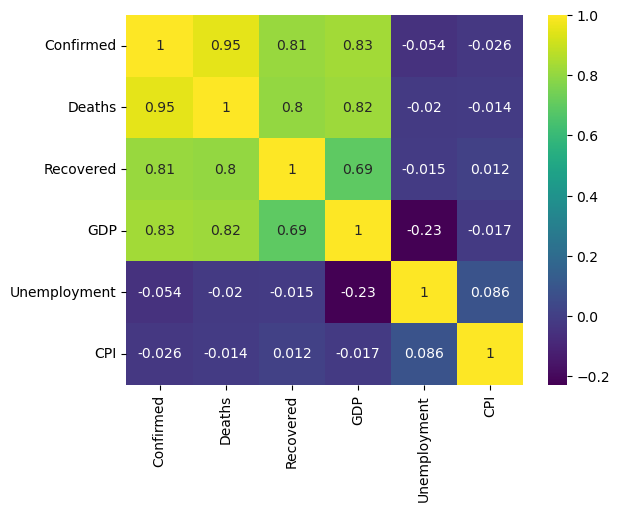

In [44]:
sns.heatmap(df.corr(),annot=True,cmap=plt.cm.viridis)

### Correlation Heatmap Insights

**Strong correlations between features and the label (GDP):**
- **Confirmed vs. GDP** — Strong positive correlation. Larger economies have larger populations and more thorough testing, leading to higher confirmed counts.
- **Deaths vs. GDP** — Strong positive correlation, for the same population/reporting reasons.
- **Recovered vs. GDP** — Positive correlation, somewhat weaker than Confirmed/Deaths because we are using only the 2021 value (more honest, but less data).

**Strong correlations between features (multicollinearity):**
- **Confirmed vs. Deaths** — Very strong positive correlation; deaths are a fraction of confirmed cases.
- **Confirmed vs. Recovered** and **Deaths vs. Recovered** — Strong positive correlations from the same population-scaling effect.
- **CaseFatality** is *deliberately* much less correlated with the count features — that is why we engineered it. It carries information about *how* a country handled COVID rather than *how big* the outbreak was.

**Weak/no correlation:**
- **Unemployment** — Weak correlation with GDP and the COVID features. Driven by structural and policy factors that do not reduce to COVID impact.
- **CPI** — Weak correlation with everything. Domestic price levels vary independently of economic size or pandemic scale.
- **CaseFatality** — Weak or mildly negative correlation with GDP, much less correlated with Confirmed/Deaths than those features are with each other.

**Key takeaway:** Confirmed and Deaths are the strongest GDP predictors but are heavily collinear. Ridge and Lasso are well-suited to this; `CaseFatality` adds a new orthogonal signal that the raw counts cannot supply on their own.


## Model Training

### Setup

- **Feature scaling:** StandardScaler (standardization)
- **Train/test split:** test_size=0.3, random_state=42
- **Evaluation metrics:** MAE, MSE, RMSE

### 1. Vanilla Linear Regression

Linear regression has no hyperparameters to tune. We use **K-fold cross-validation** (k=5) on the training set to assess model stability before evaluating on the test set.

In [45]:
from sklearn.linear_model import LinearRegression

In [ ]:
def get_metrics(model, y_test, y_hat, feature_names=None, optimal_param=None, label=None):
    """Score a fitted regression model and return a structured dict.

    - feature_names: index for the coef Series (so we can see which beta belongs to which feature).
    - optimal_param: e.g. alpha for Ridge/Lasso, degree for Polynomial — printed and stored.
    - label: optional override for the model name in the results table (lets us distinguish
            two models that share a class, e.g. Vanilla LR vs Polynomial-degree-1 LR).
    """
    mae = mean_absolute_error(y_test, y_hat)
    mse = mean_squared_error(y_test, y_hat)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_hat)

    name = label if label is not None else model.__class__.__name__
    print(f"Model: {name}")
    if optimal_param is not None:
        print(f"  Optimal param: {optimal_param}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R^2:  {r2:.4f}")

    coefs = None
    if hasattr(model, "coef_") and feature_names is not None:
        coefs = pd.Series(model.coef_, index=feature_names).round(4)
        print("  Beta coefficients:")
        for feat, val in coefs.items():
            print(f"    {feat:<14} {val:>9.4f}")

    return {
        "Name": name,
        "OptimalParam": optimal_param,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Coefs": coefs,
    }


In [47]:
results = {}

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
scaler = StandardScaler()
scaled_x_train = scaler.fit_transform(X_train)
scaled_x_test = scaler.transform(X_test)


In [49]:
model = LinearRegression()
scores = cross_val_score(model,scaled_x_train,y_train,scoring='neg_mean_squared_error',cv=5)
print(scores)
print(abs(scores.mean()))

[-2.01028519 -0.82898037 -1.34683494 -0.98827619 -1.2657231 ]
1.2880199601253186


In [50]:
model.fit(scaled_x_train,y_train)
y_hat = model.predict(scaled_x_test)

In [ ]:
metrics = get_metrics(model, y_test, y_hat, feature_names=X.columns, label="LinearRegression")
results[metrics["Name"]] = metrics


### 2. Ridge Regression

Ridge regression adds L2 regularization to handle multicollinearity. We use **RidgeCV** to find the optimal alpha (regularization strength) by testing values from 1 to 999.

In [52]:
from sklearn.linear_model import RidgeCV,Ridge

In [ ]:
# Logspace covers many orders of magnitude — the natural scale for regularization strength.
alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, scoring="neg_root_mean_squared_error")
ridge_cv.fit(scaled_x_train, y_train)
ridge_cv.alpha_


The optimal alpha is selected by `RidgeCV` from a 100-point logspace grid spanning `1e-3` to `1e3`. The exact value will be printed by the cell above; we use it directly in the next cell instead of hardcoding it.


In [ ]:
model = Ridge(alpha=ridge_cv.alpha_)
model.fit(scaled_x_train, y_train)
y_hat = model.predict(scaled_x_test)


In [ ]:
metrics = get_metrics(model, y_test, y_hat, feature_names=X.columns, optimal_param=ridge_cv.alpha_)
results[metrics["Name"]] = metrics


### 3. Lasso Regression

Lasso regression adds L1 regularization, which can zero out coefficients entirely — performing **feature selection**. We use **LassoCV** to find the optimal alpha automatically.

In [56]:
from sklearn.linear_model import LassoCV,Lasso


In [ ]:
lasso_cv = LassoCV(eps=0.001, n_alphas=200, max_iter=10000)
lasso_cv.fit(scaled_x_train, y_train)
lasso_cv.alpha_


The optimal alpha is selected automatically by `LassoCV` along its built-in regularization path (200 candidate values). The printed value will be used directly in the next cell.


In [ ]:
model = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
model.fit(scaled_x_train, y_train)
y_hat = model.predict(scaled_x_test)


In [ ]:
metrics = get_metrics(model, y_test, y_hat, feature_names=X.columns, optimal_param=lasso_cv.alpha_)
results[metrics["Name"]] = metrics


### 4. Polynomial Regression

Polynomial regression creates interaction and higher-order terms from the features. We test degrees 1 through 6, comparing train vs. test RMSE to identify the optimal degree before overfitting occurs.

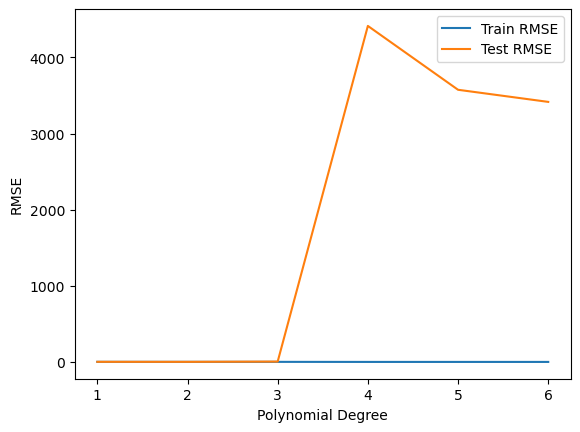

In [60]:
from sklearn.preprocessing import PolynomialFeatures
train_rmse_errors = []
test_rmse_errors = []

for degree in range(1, 7):
    polynomial_converter = PolynomialFeatures(degree=degree, include_bias=False)
    poly_x_train = polynomial_converter.fit_transform(scaled_x_train)
    poly_x_test = polynomial_converter.transform(scaled_x_test)

    model = LinearRegression()
    model.fit(poly_x_train, y_train)

    train_predictions = model.predict(poly_x_train)
    test_predictions = model.predict(poly_x_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

    train_rmse_errors.append(train_rmse)
    test_rmse_errors.append(test_rmse)

plt.plot(range(1, 7), train_rmse_errors, label="Train RMSE")
plt.plot(range(1, 7), test_rmse_errors, label="Test RMSE")
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.legend()
plt.show()


**Conclusion:** The optimal degree is selected automatically in the next cell as the one minimizing test RMSE. With only ~118 training samples and 6 features, higher degrees rapidly overfit (e.g., degree 3 already produces 83 polynomial features, degree 4 produces ~209) so we expect the elbow to land at degree 1 or 2.

In [ ]:
best_degree = int(np.argmin(test_rmse_errors)) + 1
print(f"Best polynomial degree: {best_degree}")

polynomial_converter = PolynomialFeatures(degree=best_degree, include_bias=False)
poly_x_train = polynomial_converter.fit_transform(scaled_x_train)
poly_x_test = polynomial_converter.transform(scaled_x_test)
model = LinearRegression()
model.fit(poly_x_train, y_train)
y_hat = model.predict(poly_x_test)


In [ ]:
poly_feature_names = polynomial_converter.get_feature_names_out(X.columns)
metrics = get_metrics(
    model, y_test, y_hat,
    feature_names=poly_feature_names,
    optimal_param=f"degree={best_degree}",
    label="Polynomial",
)
results[metrics["Name"]] = metrics


## Multi Model Evaluation and Deployment

### Comparison of All Models' Metrics

In [ ]:
metric_cols = ["OptimalParam", "MAE", "MSE", "RMSE", "R2"]
plot_df = pd.DataFrame(
    {name: {k: m[k] for k in metric_cols} for name, m in results.items()}
).T
# LinearRegression has no hyperparameter to tune — show that explicitly instead of NaN
plot_df["OptimalParam"] = plot_df["OptimalParam"].fillna("N/A")
plot_df

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, metric in zip(axes, ["MAE", "MSE", "RMSE", "R2"]):
    plot_df[metric].plot(kind="bar", ax=ax, title=metric, color=["steelblue", "orange", "green", "purple"])
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


### Best Model Selection

We pick the model with the lowest test-set RMSE. The next cell does this programmatically off the `results` dict so the choice always matches whatever the run produced (no hardcoded winner).

For multicollinear feature sets like ours (Confirmed/Deaths/Recovered are heavily correlated), Ridge typically outperforms vanilla Linear Regression and Lasso because the L2 penalty stabilizes the correlated coefficients without zeroing useful signal. Lasso may match or come close if it decides the model only needs a subset of the features. Polynomial regression rarely helps with only ~169 country-level rows — degree-2 already creates more features than the data can support without overfitting.

### Train the Optimal Model on the Entire Dataset

We re-fit the scaler on the full dataset (X), then retrain the chosen model on all available data using the hyperparameter that won during cross-validation.


In [ ]:
# Pick the best model by test RMSE
best_name = min(results, key=lambda k: results[k]["RMSE"])
best = results[best_name]
print(f"Best model: {best_name}  (RMSE={best['RMSE']:.4f}, optimal param={best['OptimalParam']})")

# Reconstruct the chosen estimator with the same hyperparameter
if best_name == "Ridge":
    final_model = Ridge(alpha=best["OptimalParam"])
elif best_name == "Lasso":
    final_model = Lasso(alpha=best["OptimalParam"], max_iter=10000)
elif best_name == "Polynomial":
    # OptimalParam is a string like "degree=2" — parse out the int
    deg = int(str(best["OptimalParam"]).split("=")[1])
    final_polynomial_converter = PolynomialFeatures(degree=deg, include_bias=False)
else:  # LinearRegression
    final_model = LinearRegression()

# Refit scaler on the full data; refit model on all rows.
scaler = StandardScaler()
scaled_x_full = scaler.fit_transform(X)

if best_name == "Polynomial":
    final_x_full = final_polynomial_converter.fit_transform(scaled_x_full)
    final_model = LinearRegression()
    final_model.fit(final_x_full, y)
else:
    final_polynomial_converter = None
    final_model.fit(scaled_x_full, y)

final_model


### Export to Joblib

Save the trained model, scaler, and polynomial converter to separate `.joblib` files for future use.

In [ ]:
from joblib import dump, load
dump(final_model, "final_gdp_model.joblib")
dump(scaler, "scaler_gdp.joblib")
if final_polynomial_converter is not None:
    dump(final_polynomial_converter, "polynomial_converter_gdp.joblib")


### Import from Joblib

Load the model and preprocessing instances back into fresh variables.

In [ ]:
loaded_model = load("final_gdp_model.joblib")
loaded_scaler = load("scaler_gdp.joblib")
loaded_poly = load("polynomial_converter_gdp.joblib") if final_polynomial_converter is not None else None


### Test the Loaded Model

Take a sample from X, preprocess it with the loaded scaler and polynomial converter, and generate a prediction to verify everything works.

In [ ]:
sample = X.iloc[:1]
scaled_x = loaded_scaler.transform(sample)
if loaded_poly is not None:
    scaled_x = loaded_poly.transform(scaled_x)
predictions = loaded_model.predict(scaled_x)
print(f"Predicted (log-GDP): {predictions[0]:.4f}, Actual (log-GDP): {y.iloc[0]:.4f}")
print(f"Predicted (USD):     {np.expm1(predictions[0]):.2e}, Actual (USD):     {np.expm1(y.iloc[0]):.2e}")
